# gabella2021 — Gabella (2021) Topology of Learning

Mapper on weight trajectories: filter = L2 norm of the parameter vector.  Several runs from one initialisation give a **tree-like** learning topology.


## What the paper does

Views *training itself* as a curve through weight space and visualises it with **Mapper**. The parameter vectors `{W_i}` snapshotted along training are the point cloud; the lens is the **`L2` norm** of the parameter vector (a proxy for 'how far from initialisation'); Mapper then summarises the optimisation path as a graph.

**Methodology:** weight trajectories `{W_i}` → `L2`-norm lens → Mapper graph of the learning path.

**Expected result:** the Mapper graph is **tree-like**, branching out from the initialisation origin as training explores weight space (their Fig. 5).

> **Why several runs.** A *single* SGD run is a 1-D path and its `L2` norm grows roughly monotonically, so Mapper returns one **curve**, not a tree.  Branches appear when several trajectories **share an origin** — so we train a few models from the *same initialisation* with different batch orders and Mapper them together.  (Explicit extraction on purpose: Mapper needs the trajectories as one `(T, D)` point cloud, which the activations-oriented model-first adapter would not build.)


## Dataset & model in the paper

- **arXiv:** [https://arxiv.org/abs/1902.08160](https://arxiv.org/abs/1902.08160)
- **Venue:** EPFL technical report / preprint
- **Datasets used:** MNIST.
- **Models used:** Small fully-connected ReLU networks trained from scratch.
- **Headline result to aim for:** L2-norm-filter Mapper of the weight trajectory shows tree topology branching from the initialisation origin (Fig. 5).
- **Reference code:** [https://github.com/maximevictor/topo-learning](https://github.com/maximevictor/topo-learning)

To reproduce paper numbers, replace the synthetic-data cell below with the real model snapshot / activations / trajectory.  Everything else in the notebook stays the same.


**This notebook runs on real data.**  A few tiny MLPs are trained briefly on the local MNIST cache; the qualitative tree the paper reports should appear.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # make `paper_reproduce` importable
import numpy as np
import matplotlib.pyplot as plt
import torch
from tanc import TDAPipeline
from paper_reproduce._torch_setup import (
    load_mnist, load_fashion_mnist, load_cifar10, load_cifar100,
    SmallMLP, SmallCNN, CNN_FCN, CNN_FCN2, train_briefly, extract_snapshot, pick_device,
)
np.random.seed(0); torch.manual_seed(0)
DEVICE = pick_device()                      # 'cuda' → 'mps' (Apple GPU) → 'cpu'


## 1. Train several runs from one initialisation


In [2]:
import copy
from tanc.model_extractor import TrainingExtractor

N_RUNS = 6                       # branches that share a common root
X_tr, y_tr = load_mnist('train', n_samples=2000)
X_te, y_te = load_mnist('test',  n_samples=400)

# One fixed initialisation shared by every run.
base = SmallMLP(input_dim=784, hidden_dims=[32, 16], output_dim=10)

def run_trajectory(seed):
    '''Train a copy of `base` (same init, different batch order) and
    return its weight trajectory flattened to (T, D).'''
    model = copy.deepcopy(base)
    torch.manual_seed(seed)
    ext = TrainingExtractor(
        model=model, train_data=(X_tr, y_tr), batch_size=64,
        criterion=torch.nn.CrossEntropyLoss(),
        optimizer=torch.optim.Adam(model.parameters(), lr=1e-3),
        val_data=(X_te, y_te), extract_data=X_te[:64],
        aspects=['weights'], snapshot_every=2,
        snapshot_schedule='iteration', device=DEVICE, clarify=False,
    )
    view = ext.run(epochs=3, target_accuracy=None, verbose=False)
    return np.stack([np.concatenate([w.ravel() for w in snap_w])
                     for snap_w in view.weight_trajectory()])

trajectories = [run_trajectory(s) for s in range(N_RUNS)]
print(f'{N_RUNS} runs x {len(trajectories[0])} snapshots each')


6 runs x 48 snapshots each


## 2. Concatenate the trajectories into one point cloud


In [3]:
# Each run is one branch; they share the common initialisation as root.
data   = np.concatenate(trajectories, axis=0)            # (sum T, D)
run_id = np.concatenate([np.full(len(t), i)
                         for i, t in enumerate(trajectories)])
print(f'weight-trajectory point cloud: {data.shape}')


weight-trajectory point cloud: (288, 25760)


## 3. Reproduce via `TDAPipeline.from_paper`

A slightly finer Mapper cover (`n_intervals=15`, `overlap_frac=0.4`) resolves the branch points where the runs diverge.


In [4]:
pipe = TDAPipeline.from_paper("gabella2021",
                            tool_kwargs__n_intervals=15,
                            tool_kwargs__overlap_frac=0.4)
pipe.explain()


TDAPipeline — Gabella (2021)
  Stage 1: builder = activation_graph
             distance = 'euclidean'
  Stage 2: tool    = mapper
             filter_fn = 'l2_norm'
             n_intervals = 15
             overlap_frac = 0.4
  Default plot   : .plot('graph')


"TDAPipeline — Gabella (2021)\n  Stage 1: builder = activation_graph\n             distance = 'euclidean'\n  Stage 2: tool    = mapper\n             filter_fn = 'l2_norm'\n             n_intervals = 15\n             overlap_frac = 0.4\n  Default plot   : .plot('graph')"

TopoResult(tool='mapper')
  paper       : Gabella (2021)
  data        : mapper_graph (36 nodes)
  plots       :
    .plot('graph') — Node-link drawing of the Mapper graph.
  config keys : filter_fn, n_components, n_intervals, overlap_frac, compute_ph


"TopoResult(tool='mapper')\n  paper       : Gabella (2021)\n  data        : mapper_graph (36 nodes)\n  plots       :\n    .plot('graph') — Node-link drawing of the Mapper graph.\n  config keys : filter_fn, n_components, n_intervals, overlap_frac, compute_ph"

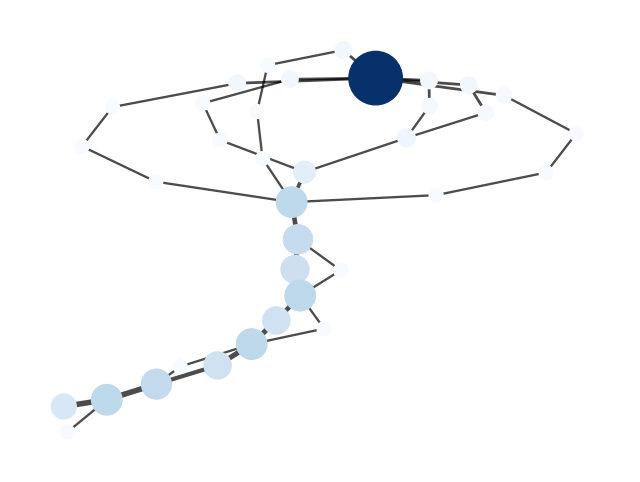

In [5]:
result, fig = pipe.reproduce(data)
result.describe()


## 4. The learning tree — coloured by run

Nodes are coloured by which run their snapshots come from; the shared early-training nodes form the root and the runs fan out into branches.


nodes=36  edges=43  branch nodes (deg>2)=9  components=1


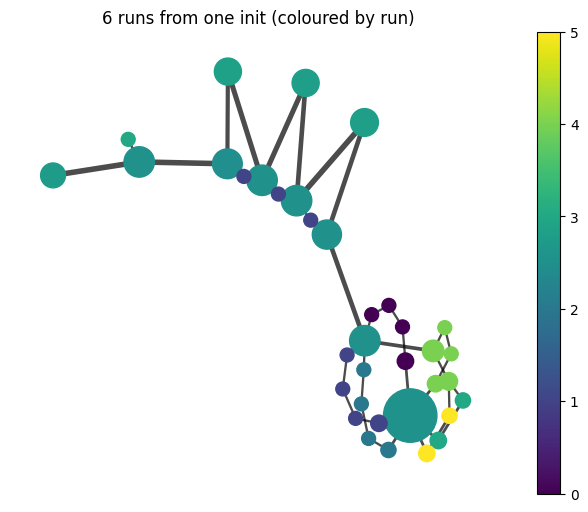

In [6]:
import networkx as nx
fig = result.plot('graph', color_by=run_id, layout='kamada_kawai',
                  title=f'{N_RUNS} runs from one init (coloured by run)')
g = result.mapper.graph
branch = sum(1 for _, d in g.degree() if d > 2)
print(f'nodes={g.number_of_nodes()}  edges={g.number_of_edges()}  '
      f'branch nodes (deg>2)={branch}  '
      f'components={nx.number_connected_components(g)}')


## Notes & gaps

* Implements the method as described,: the tree-like learning topology from several real weight trajectories sharing one initialisation.  A *single* run instead gives one curve (set `N_RUNS=1` to see it).
* More branches: raise `N_RUNS`, or nudge `tool_kwargs__n_intervals` / `overlap_frac`.  Colour by training step instead with `color_by=np.arange(len(data))`.
* Secondary 2-D PCA *surface* analysis: re-run with `from_paper('gabella2021', tool_kwargs__filter_fn='pca', tool_kwargs__n_components=3)`.


## Deviations from the paper

Everything this notebook does differently from the source, and why. An empty
table below means the construction follows the paper as written — that is a
claim, not an omission. Scale always differs; see the last row.

| aspect | the paper | this notebook | why it matters |
|---|---|---|---|
| scale | the paper's full experimental setup | a smaller model, fewer samples, fewer epochs | to keep the notebook runnable in minutes; expect weaker effects than published |
